In [12]:
#Importamos las librerias para poder visualizar el mapa exportado desde figma, primero el .png con los trazados manuales que se hice
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


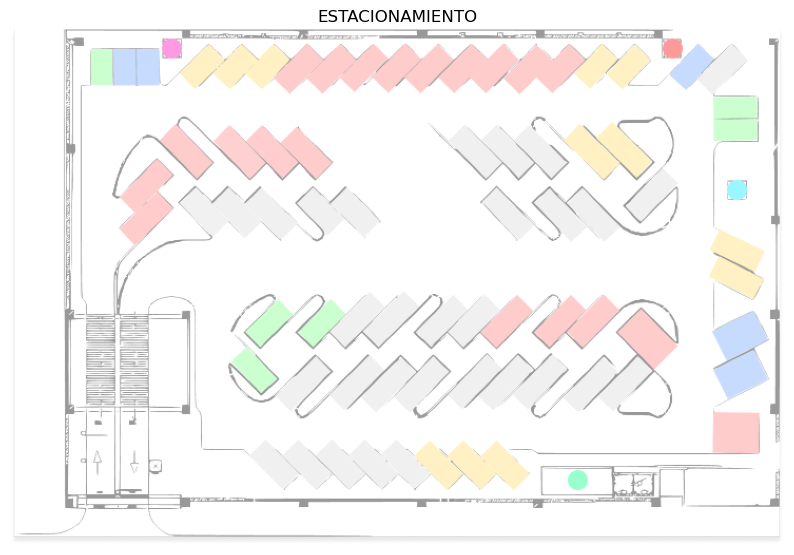

In [16]:
fig, ax = plt.subplots(figsize=(10,9)) #Creamos el lienzo apartir de los ejes de un grafico, definimos fig = figure y ax = axes osea el contenido
#14,9 es la dimensión de la cuadricula osea 10 pulgadas de ancho x 9 pulgadas de alto

try:
    img = mpimg.imread('Mapa_SmartParking.png') #Leemos el archivo png para mostrarlo
    ax.imshow(img, extent=[0, img.shape[1], img.shape[0], 0], alpha=0.4) #Mostramos el contenido de la variable img que contiene la imagen
    
except:
    ax.invert_yaxis()
    
ax.set_title("ESTACIONAMIENTO")
ax.axis('off') #Instruccion para quitarle los ejes en x,y
plt.show()

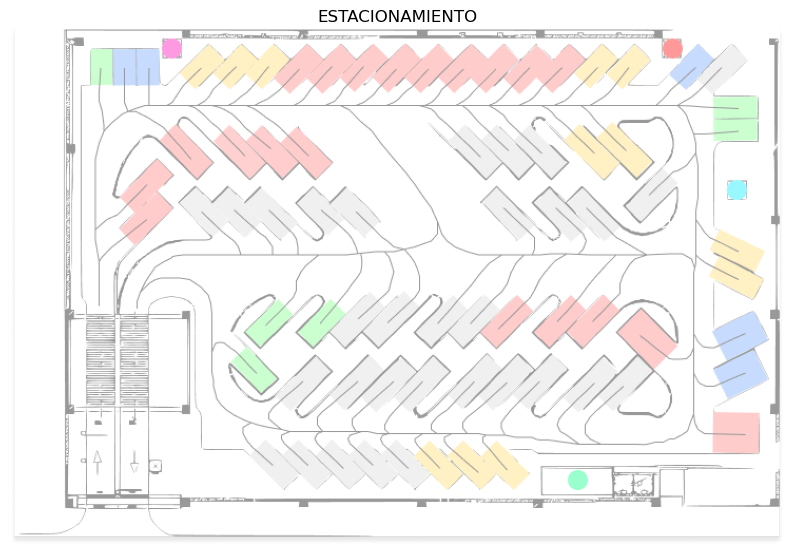

In [17]:
# El siguiente paso será, cargar el png pero ahora con las rutas para visualizar por donde pasara nuestro algoritmo

fig, ax = plt.subplots(figsize=(10,9)) #Creamos el lienzo apartir de los ejes de un grafico, definimos fig = figure y ax = axes osea el contenido
#14,9 es la dimensión de la cuadricula osea 10 pulgadas de ancho x 9 pulgadas de alto

try:
    img = mpimg.imread('Mapa_SmartParking_ruta.png') #Leemos el archivo png para mostrarlo
    ax.imshow(img, extent=[0, img.shape[1], img.shape[0], 0], alpha=0.4) #Mostramos el contenido de la variable img que contiene la imagen
    
except:
    ax.invert_yaxis()
    
ax.set_title("ESTACIONAMIENTO")
ax.axis('off') #Instruccion para quitarle los ejes en x,y
plt.show()

In [21]:
#Ahora será necesario trazar los nodos para evaluar si están todos correctamente conectados

import xml.etree.ElementTree as ET #Biblioteca para parsear XML a Python, el .svg es puro codigo XML, osea codigo constituido en mayor parte por
# lineas, poligonos, caminos que se basan en patrones curvos, formas y colores, es un grafica vectorial
import re # Biblioteca para manipular el texto utilizando Regular Expressions, especialmente para eliminar, actualizar o extrar letras o numeros
import math #Biblioteca para funciones matematicas
import networkx as nx # 

In [45]:
#Mencion de uso de IA en extraccion de codigo XML en el .svg
def grafo_total(ruta_svg): #Ponemos como parametro el .svg que es la imagen ya vectorizada
    arbol = ET.parse(ruta_svg) #Parseamos (traducir) a una variable arbol todo el contenido del .svg como si fuese un arbol
    raiz = arbol.getroot() #Obtenemos la raiz del nodo del arbol que acabamos de inicializar
    ns = {'svg': 'http://www.w3.org/2000/svg'} #namespace para que la funcion elementTree busque etiquetas tipo
    # <path> o <line> o <g>
    
    G = nx.Graph() #Instanaciamos un objeto de tipo grafo donde se guardaran todos los nodos que se vayan encontrando
    
    grafo = None #Variable temporal
    
    # Vamos a recorrer de forma recursiva los elementos del svg buscando el path que declaré como grafo rutas
    # desde figma que es la ruta gris de la imagen de arriba
    for p in raiz.iter():
        if 'graforutas' in p.get('id', '').lower():
            grafo = p
            break
        
    if grafo == None:
        return ValueError("No se encontró el path graforutas")
    
    rutas = [] #Inicializamos una lista que almacena el valor del atributo osea las coordenadas de cada elemento en el path
    
    #Basicamente si el tag que contiene grafo actualmente siempre termina en </path> va a ir metiendo el valor de cada vector
    # en la lista rutas, se le pone d, porque esta es la variable en el .svg que contiene toda la ruta xml
    if grafo.tag.endswith('path'):
        rutas.append(grafo.get('d', ''))
    else:
        for path in grafo.findall('.//svg:path', ns):
            rutas.append(path.get('d', '')) # Si no es </path> busca los elementos descendientes de path utilizando
            #el namespace y agrega los atributos d de cada uno en la lista
    #Necesitamos extraer los comandos en las cadenas de texto puesto que estas nos indicaran el orden de trazado
    for atributo in rutas:
        #Extraemos letras tanto mayusculas como minusculas, numeros negativos y positivos, decimales y enteros
        # , con la funcion re, separa cadena de texto del trazado en elementos individuales y se guarda en la variable tokens
        tokens = re.findall(r'[A-Za-z]|[-+]?\d*\.?\d+', atributo)
        
        actual = 'M' #M representa Move to, indicamos el estado inicial del trazador
        i = 0
        x_actual, y_actual = 0.0, 0.0
        nodo_anterior = None #Necesitamos guardar el padre del nodo siguiente para ir conectando los nodos
    
        while i < len(tokens):
            token = tokens[i] #Comenzamos el bucle para procesar el token uno por uno
            
            #Vienen las condicionales
            
            #Si el token es una letra
            if token.isalpha():
                actual = token.upper() #Mayusculas para estandarizar
                i += 1 #Incrementamos el indice para leer el siguiente token
                continue
            
            if actual in ['M', 'L']: # L = Line to, es para lineas rectas que no son ni verticales ni horizontales
                #osea estan como en diagonal pero son rectas, M es para moverse de punto en punto
                # Ambos comandos tanto M L les extramos las coordenadas en x,y mediante indices
                if i + 1 < len(tokens):
                    x_actual = float(tokens[i])
                    y_actual = float(tokens[i+1])
                    i += 2
            
            elif actual == 'H': #Para lineas horizontales
                x_actual = float(tokens[i])
                i += 1 
                
            elif actual == 'V': #Para lineas verticales
                y_actual = float(tokens[i])
                i += 1
            
            elif actual == 'C': #Para curvas
                #En estos casos figma siempre da 6 coordenadas para cuando son curvas
                if i + 5 < len(tokens):
                    # Agregamos los puntos intermedios de la curva para que no se vea como recta
                    cx1, cy1 = float(tokens[i]), float(tokens[i+1])
                    cx2, cy2 = float(tokens[i+2]), float(tokens[i+3])
                    x_actual, y_actual = float(tokens[i+4]), float(tokens[i+5])
                    
                    G.add_node((cx1, cy1), pos=(cx1, cy1))
                    G.add_node((cx2, cy2), pos=(cx2, cy2))
                    G.add_node((x_actual, y_actual), pos=(x_actual, y_actual))
                    
                    if nodo_anterior: #En la prinera iteracion no entra porque está vacio el nodo_anterior
                        G.add_edge(nodo_anterior, (cx1, cy1), weight=math.hypot(cx1 - nodo_anterior[0], cy1 - nodo_anterior[1]))
                    G.add_edge((cx1, cy1), (cx2, cy2), weight=math.hypot(cx2 - cx1, cy2 - cy1))
                    G.add_edge((cx2, cy2), (x_actual, y_actual), weight=math.hypot(x_actual - cx2, y_actual - cy2))
                    
                    nodo_anterior = (x_actual, y_actual) #Aqui vamos guardando el historial de cada nodo
                    i += 6
                    continue
            else: #Para otros comandos no soportados
                i += 1
                continue
            #Agregamos al nodo actual para las rectas
            nodo_actual = (x_actual, y_actual)
            G.add_node(nodo_actual, pos=nodo_actual)
            
            # Conectamos con el nodo anterior si no levantamos la pluma (M), me refiero a levantar la pluma cuando
            # en figma presiono esc para terminar el punto del vector 
            if actual != 'M' and nodo_anterior and nodo_anterior != nodo_actual:
                distancia = math.hypot(x_actual - nodo_anterior[0], y_actual - nodo_anterior[1])
                G.add_edge(nodo_anterior, nodo_actual, weight=distancia)  #Conectamos el nodo_padre con el nodo_actual
                #con la funcion add_edge que conecta mediante una arista los dos nodos y se le agrega una distancia calculada
                #para darle peso para despues indicarle al algoritmo el costo
                
            nodo_anterior = nodo_actual
            
            
    return G
        
grafo_parking = grafo_total('Mapa_SmartParking.svg')
print("Numero de nodos conectados: ",grafo_parking.number_of_nodes())    

Numero de nodos conectados:  666


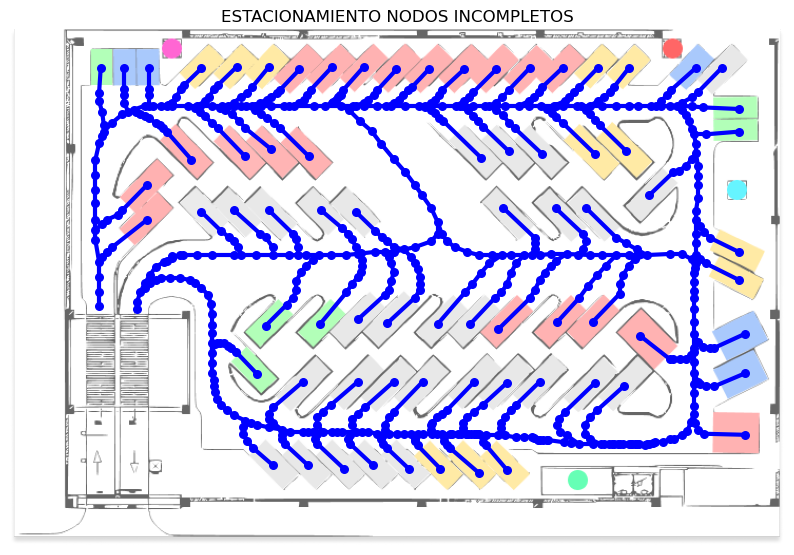

In [ ]:
# Para imprimir nuestro plano con nuestros nodos conectados tendriamos que mandar a llamar de manera 
# iterativa cada uno para que se vaya enlistando e imprimiendo

fig, ax = plt.subplots(figsize=(10,9))

try:
    img = mpimg.imread('Mapa_SmartParking_ruta.png') #Leemos el archivo png para mostrarlo
    ax.imshow(img, extent=[0, img.shape[1], img.shape[0], 0], alpha=0.6) #Mostramos el contenido de la variable img que contiene la imagen  
except:
    ax.invert_yaxis()
    
conexiones = list(nx.connected_components(grafo_parking))
conexiones.sort(key=len, reverse=True) #De lo más grande a lo más chico

for i, componente in enumerate(conexiones):

    subgrafo = grafo_parking.subgraph(componente)
    
    for u,v in subgrafo.edges():
        ax.plot([u[0], v[0]] , [u[1], v[1]], color='blue', linewidth=3)
    
    #Para dibujar los puntos
    x_coords = [n[0] for n in subgrafo.nodes()]
    y_coords = [n[1] for n in subgrafo.nodes()]
    ax.scatter(x_coords, y_coords, color='blue', s=30)
    
ax.set_title("ESTACIONAMIENTO NODOS")
ax.axis('off') #Instruccion para quitarle los ejes en x,y
plt.show()

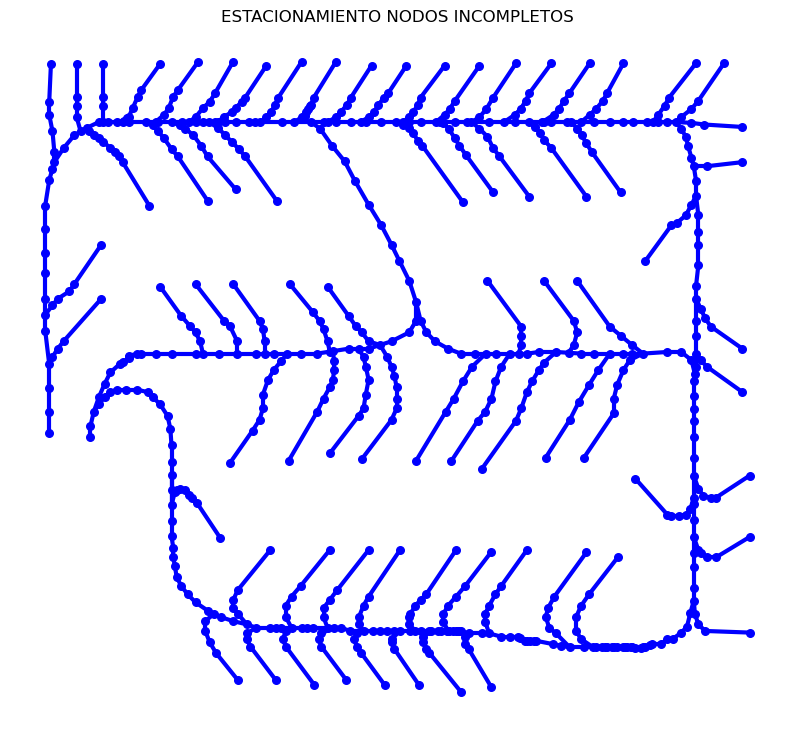

In [ ]:
fig, ax = plt.subplots(figsize=(10,9))
ax.invert_yaxis()

conexiones = list(nx.connected_components(grafo_parking))
conexiones.sort(key=len, reverse=True) #De lo más grande a lo más chico

for i, componente in enumerate(conexiones):

    subgrafo = grafo_parking.subgraph(componente)
    
    for u,v in subgrafo.edges():
        ax.plot([u[0], v[0]] , [u[1], v[1]], color='blue', linewidth=3)
    
    #Para dibujar los puntos
    x_coords = [n[0] for n in subgrafo.nodes()]
    y_coords = [n[1] for n in subgrafo.nodes()]
    ax.scatter(x_coords, y_coords, color='blue', s=30)
    
ax.set_title("NODOS")
ax.axis('off') #Instruccion para quitarle los ejes en x,y
plt.show()